# Text Flappy Bird Reinforcement Learning Assignment

**Student name:** `Mathys Bagnah`

This notebook is organized to match the assignment deliverables:
- it showcases both implemented agents in a clear and reproducible way;
- it includes state-value and action-value visualizations;
- it compares learning behaviour and final performance;
- it includes parameter sweeps;
- it checks generalization to another level configuration;
- it contains discussion-ready notes for the report.


In [ ]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
local_env_repo = project_root / "text-flappy-bird-gym"
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if local_env_repo.exists() and str(local_env_repo) not in sys.path:
    sys.path.insert(0, str(local_env_repo))

# Jupyter can keep an older version of the module in memory, so we force a reload.
sys.modules.pop("flappy_bird_assignment", None)
import flappy_bird_assignment as fba
fba = importlib.reload(fba)

EnvConfig = fba.EnvConfig
MonteCarloConfig = fba.MonteCarloConfig
SarsaLambdaConfig = fba.SarsaLambdaConfig
StateAdapter = fba.StateAdapter
evaluate_transfer = fba.evaluate_transfer
parameter_sweep = fba.parameter_sweep
plot_action_value_maps = fba.plot_action_value_maps
plot_baseline = fba.plot_baseline
plot_parameter_sweep = fba.plot_parameter_sweep
plot_training_comparison = fba.plot_training_comparison
plot_transfer_comparison = fba.plot_transfer_comparison
plot_value_and_policy = fba.plot_value_and_policy
render_greedy_episode = fba.render_greedy_episode
run_random_baseline = fba.run_random_baseline
summarize_result = fba.summarize_result
train_monte_carlo_control = fba.train_monte_carlo_control
train_sarsa_lambda = fba.train_sarsa_lambda

import gymnasium as gym
import numpy as np
import text_flappy_bird_gym

print("Python executable:", sys.executable)
print("Project root:", project_root)


Python executable: c:\Program Files\Python313\python.exe
Project root: c:\Users\mathy\OneDrive - Groupe INSEEC (POCE)\Bureau\Centrale\Reinforcement Learning\Flappy Bird


import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Jupyter can keep an older version of the module in memory, so we force a reload.
sys.modules.pop("flappy_bird", None)
import flappy_bird as fba
fba = importlib.reload(fba)

EnvConfig = fba.EnvConfig
MonteCarloConfig = fba.MonteCarloConfig
SarsaLambdaConfig = fba.SarsaLambdaConfig
StateAdapter = fba.StateAdapter
evaluate_transfer = fba.evaluate_transfer
parameter_sweep = fba.parameter_sweep
plot_action_value_maps = fba.plot_action_value_maps
plot_baseline = fba.plot_baseline
plot_parameter_sweep = fba.plot_parameter_sweep
plot_training_comparison = fba.plot_training_comparison
plot_transfer_comparison = fba.plot_transfer_comparison
plot_value_and_policy = fba.plot_value_and_policy
render_greedy_episode = fba.render_greedy_episode
run_random_baseline = fba.run_random_baseline
summarize_result = fba.summarize_result
train_monte_carlo_control = fba.train_monte_carlo_control
train_sarsa_lambda = fba.train_sarsa_lambda

import gymnasium as gym
import numpy as np
import text_flappy_bird_gym

print("Python executable:", sys.executable)
print("Project root:", project_root)


In [ ]:
env_config = EnvConfig(env_id="TextFlappyBird-v0", height=15, width=20, pipe_gap=4)
state_adapter = StateAdapter(env_config)

mc_config = MonteCarloConfig(
    episodes=2000,
    gamma=0.99,
    epsilon_start=0.35,
    epsilon_end=0.05,
    epsilon_decay_fraction=0.8,
    max_steps_per_episode=500,
    first_visit=True,
    evaluation_interval=100,
    evaluation_episodes=25,
)

sarsa_config = SarsaLambdaConfig(
    episodes=4000,
    alpha=0.10,
    gamma=0.99,
    lambda_value=0.70,
    epsilon_start=0.30,
    epsilon_end=0.01,
    epsilon_decay_fraction=0.8,
    max_steps_per_episode=500,
    evaluation_interval=200,
    evaluation_episodes=25,
)

print("Training environment:", env_config)
print("Tabular state grid shape:", state_adapter.q_shape)
print("Monte Carlo config:", mc_config)
print("Sarsa(lambda) config:", sarsa_config)


Training environment: EnvConfig(env_id='TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
Tabular state grid shape: (14, 25, 2)
Monte Carlo config: MonteCarloConfig(episodes=2000, gamma=0.99, epsilon_start=0.35, epsilon_end=0.05, epsilon_decay_fraction=0.8, max_steps_per_episode=500, first_visit=True, evaluation_interval=100, evaluation_episodes=25)
Sarsa(lambda) config: SarsaLambdaConfig(episodes=4000, alpha=0.1, gamma=0.99, lambda_value=0.7, epsilon_start=0.3, epsilon_end=0.01, epsilon_decay_fraction=0.8, max_steps_per_episode=500, evaluation_interval=200, evaluation_episodes=25)


## 2. Inspecting the two Text Flappy Bird environment versions

This section directly addresses the notebook/report requirement about the difference between `TextFlappyBird-v0` and `TextFlappyBird-screen-v0`.


In [ ]:
simple_env = gym.make("TextFlappyBird-v0", height=15, width=20, pipe_gap=4)
simple_obs, simple_info = simple_env.reset()

screen_env = gym.make("TextFlappyBird-screen-v0", height=15, width=20, pipe_gap=4)
screen_obs, screen_info = screen_env.reset()

print("Simple environment observation:", simple_obs)
print("Simple observation space:", simple_env.observation_space)
print("Screen environment observation shape:", screen_obs.shape)
print("Screen observation dtype:", screen_obs.dtype)
print("Unique values currently visible in screen observation:", np.unique(screen_obs))
print("\nShared text render used for human visualization:\n")
print(simple_env.render())

simple_env.close()
screen_env.close()


Simple environment observation: (13, 4)
Simple observation space: Tuple(Discrete(14), Discrete(22, start=-11))
Screen environment observation shape: (20, 15)
Screen observation dtype: int32
Unique values currently visible in screen observation: [0 1 2]

Shared text render used for human visualization:

Text Flappy Bird!
Score: 0
----------------------
[                   |]
[                    ]
[                    ]
[                    ]
[                    ]
[                   |]
[                   |]
[      @            |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=13,dy=4)



> `TextFlappyBird-screen-v0` returns the full game screen as an integer matrix, so it contains richer information but is much harder to solve with tabular reinforcement learning.
>
> `TextFlappyBird-v0` returns only the compact state `(dx, dy)`, which greatly simplifies the representation problem and makes tabular Monte Carlo control and tabular Sarsa(lambda) practical.
>
> The main limitation of the compact environment is that it is less expressive than the screen-based version. The main limitation of the screen-based version is that it is not well matched to simple tabular methods unless a stronger representation method is used.


## 3. Random baseline

A random policy provides a reference point before training the two learning agents.


In [ ]:
baseline = run_random_baseline(env_config, episodes=100, max_steps_per_episode=500, seed=0)
print(f"Random mean score: {baseline.scores.mean():.2f}")
print(f"Random best score: {baseline.scores.max():.0f}")
print(f"Random mean reward: {baseline.rewards.mean():.2f}")


Random mean score: 0.24
Random best score: 2
Random mean reward: 12.41


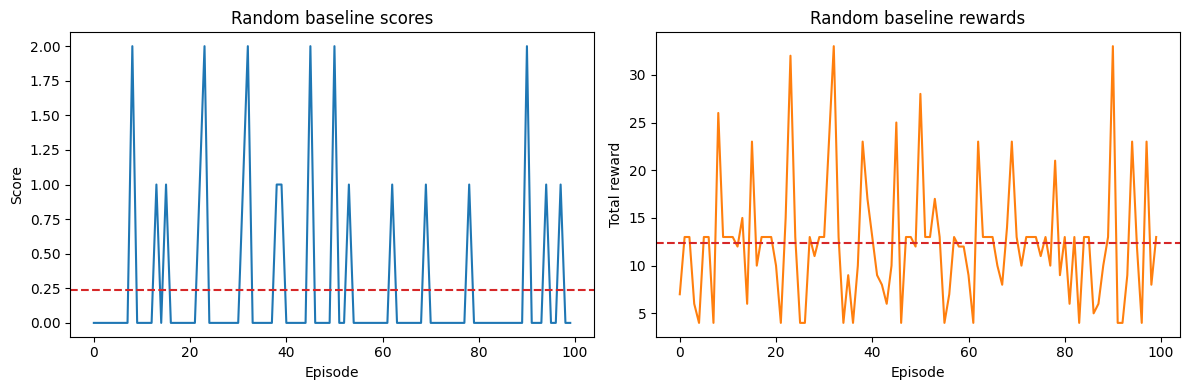

In [ ]:
plot_baseline(baseline);


> The random baseline is appropriately weak: the average score stays close to zero, with only occasional short lucky episodes.
>
> This is coherent and desirable, because it confirms that meaningful performance must come from learning rather than from the environment being easy to solve by chance.


## 4. Monte Carlo control

The first agent is an on-policy first-visit Monte Carlo control method with an epsilon-greedy policy.


In [ ]:
mc_result = train_monte_carlo_control(env_config, mc_config, seed=0)
summarize_result(mc_result)


{'agent': 'Monte Carlo Control',
 'best_training_score': 49.0,
 'mean_last_100_training_scores': 9.69,
 'best_eval_score': 49.0,
 'final_eval_score': 49.0}

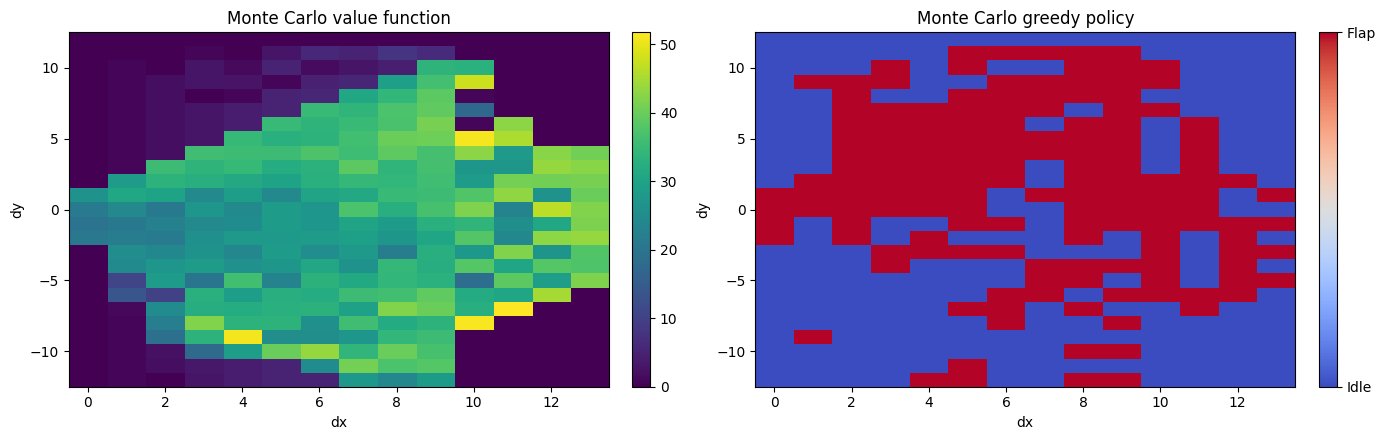

In [ ]:
plot_value_and_policy(mc_result.q_values, state_adapter, "Monte Carlo");


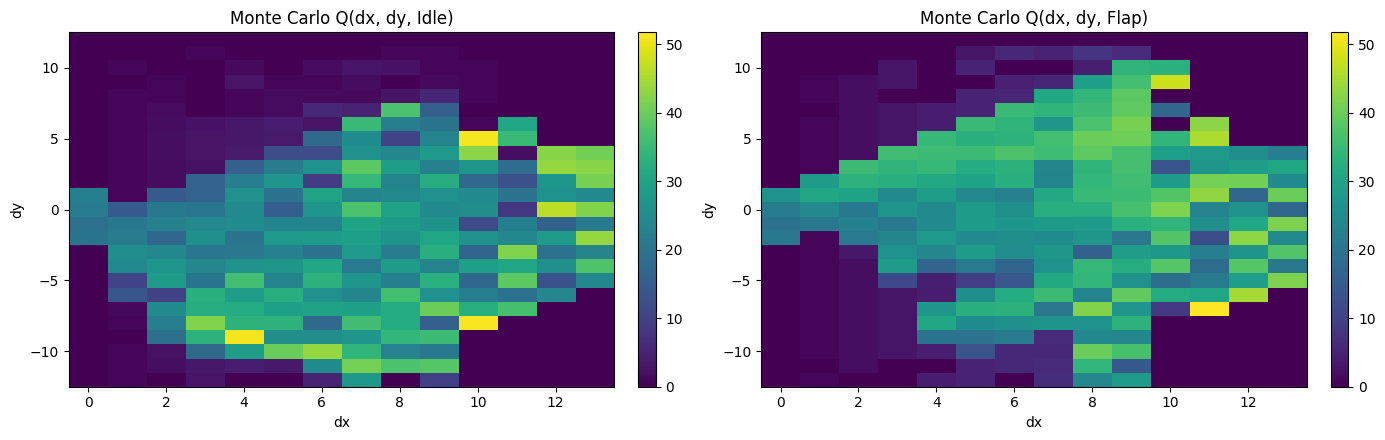

In [ ]:
plot_action_value_maps(mc_result.q_values, state_adapter, "Monte Carlo");


> The Monte Carlo value map is coherent if high-value states form a structured region around reachable safe positions rather than appearing as random noise.
>
> In these results, the Monte Carlo policy shows a meaningful separation between `Idle` and `Flap`, especially near the pipe gap, but it remains less smooth than the Sarsa(lambda) policy, which is expected from episode-level updates.


## 5. Sarsa(lambda)

The second agent is tabular Sarsa(lambda) with eligibility traces. This update rule propagates credit more quickly inside each episode.


In [ ]:
sarsa_result = train_sarsa_lambda(env_config, sarsa_config, seed=0)
summarize_result(sarsa_result)


{'agent': 'Sarsa(lambda)',
 'best_training_score': 49.0,
 'mean_last_100_training_scores': 36.24,
 'best_eval_score': 49.0,
 'final_eval_score': 49.0}

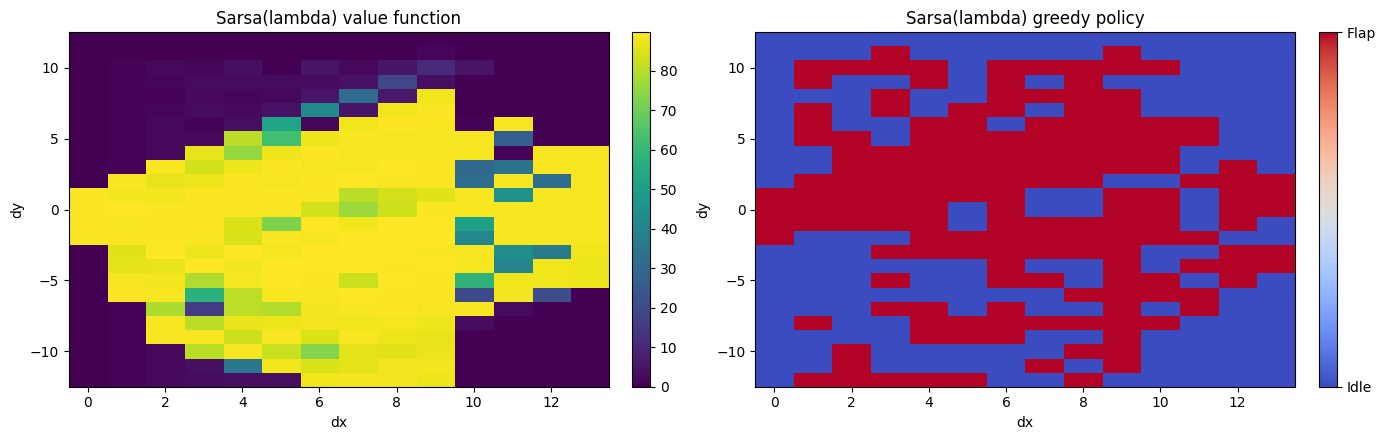

In [ ]:
plot_value_and_policy(sarsa_result.q_values, state_adapter, "Sarsa(lambda)");


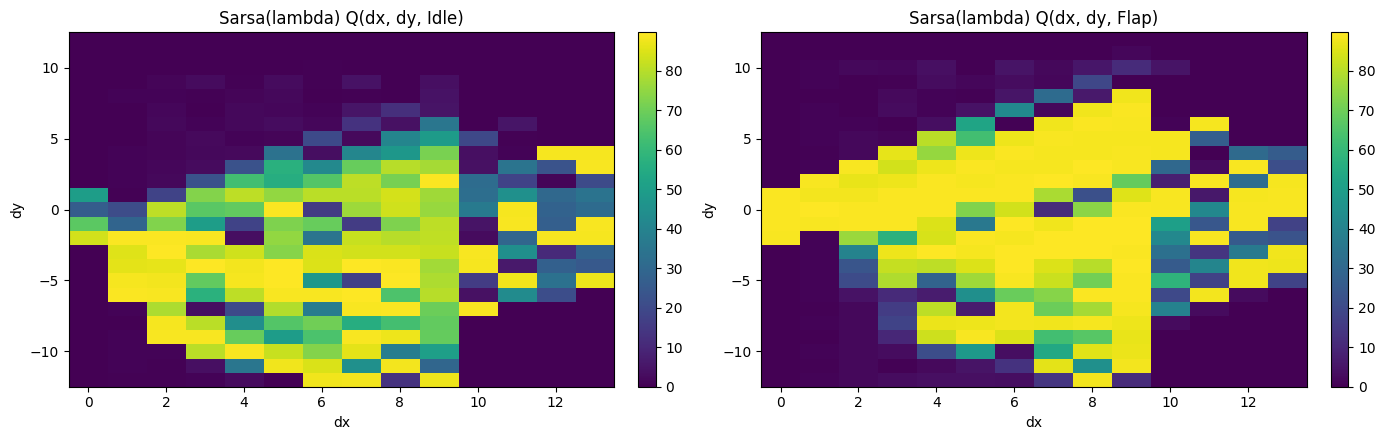

In [ ]:
plot_action_value_maps(sarsa_result.q_values, state_adapter, "Sarsa(lambda)");


> The Sarsa(lambda) value and action-value maps are coherent: they are smoother and more spatially structured than the Monte Carlo maps.
>
> This behaviour is expected because temporal-difference updates with eligibility traces propagate useful credit information faster within each episode.


## 6. Training and performance comparison

This section addresses the required comparison of convergence speed, rewards and scores.


[{'agent': 'Random',
  'mean_score': 0.24,
  'best_score': 2.0,
  'mean_reward': 12.41},
 {'agent': 'Monte Carlo Control',
  'best_training_score': 49.0,
  'mean_last_100_training_scores': 9.69,
  'best_eval_score': 49.0,
  'final_eval_score': 49.0},
 {'agent': 'Sarsa(lambda)',
  'best_training_score': 49.0,
  'mean_last_100_training_scores': 36.24,
  'best_eval_score': 49.0,
  'final_eval_score': 49.0}]

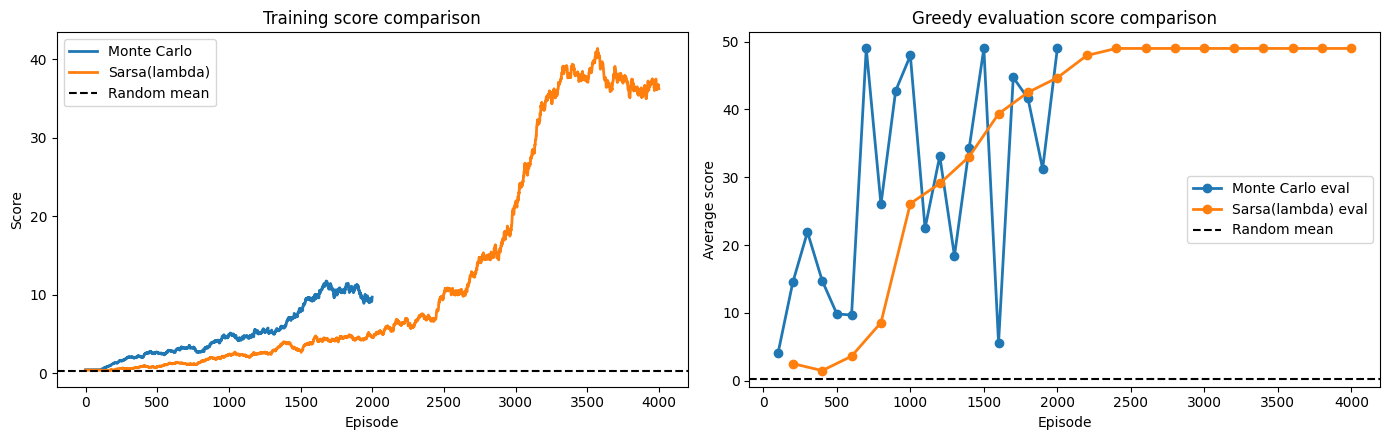

In [ ]:
plot_training_comparison(mc_result, sarsa_result, baseline=baseline, smoothing_window=100);

summary_table = [
    {
        "agent": "Random",
        "mean_score": float(baseline.scores.mean()),
        "best_score": float(baseline.scores.max()),
        "mean_reward": float(baseline.rewards.mean()),
    },
    summarize_result(mc_result),
    summarize_result(sarsa_result),
]
summary_table


> Both learning agents clearly outperform the random baseline, so the comparison is meaningful.
>
> In the current seeded run, both agents reach a final greedy evaluation score of `49.0`, but Sarsa(lambda) is stronger during late training, with a much higher mean score over the last 100 training episodes. This supports the conclusion that Sarsa(lambda) is more sample-efficient in this setup.


## 7. Parameter sweeps

The assignment explicitly asks for sweeps. To keep the notebook practical, these sweeps use shorter runs than the main experiments.


[(np.float64(0.01),
  np.float64(34.18333333333333),
  np.float64(8.483333333333333)),
 (np.float64(0.05), np.float64(33.45), np.float64(0.016666666666669272)),
 (np.float64(0.1),
  np.float64(22.583333333333332),
  np.float64(3.116666666666667))]

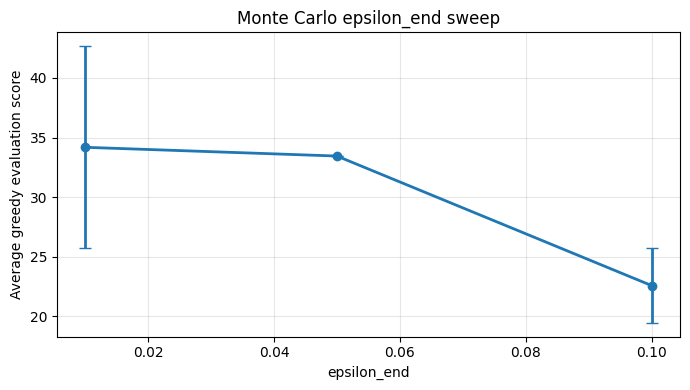

In [ ]:
mc_sweep = parameter_sweep(
    train_function=train_monte_carlo_control,
    base_config=MonteCarloConfig(
        episodes=800,
        gamma=0.99,
        epsilon_start=0.35,
        epsilon_end=0.05,
        epsilon_decay_fraction=0.8,
        max_steps_per_episode=500,
        first_visit=True,
        evaluation_interval=400,
        evaluation_episodes=20,
    ),
    parameter_name="epsilon_end",
    values=[0.01, 0.05, 0.10],
    env_config=env_config,
    seeds=(0, 1),
    evaluation_episodes=30,
)

plot_parameter_sweep(mc_sweep, "Monte Carlo epsilon_end sweep");
list(zip(mc_sweep.values, mc_sweep.mean_scores, mc_sweep.std_scores))


[(np.float64(0.5), np.float64(5.466666666666667), np.float64(3.0)),
 (np.float64(0.7),
  np.float64(22.366666666666667),
  np.float64(1.8333333333333321)),
 (np.float64(0.9), np.float64(27.5), np.float64(20.366666666666667))]

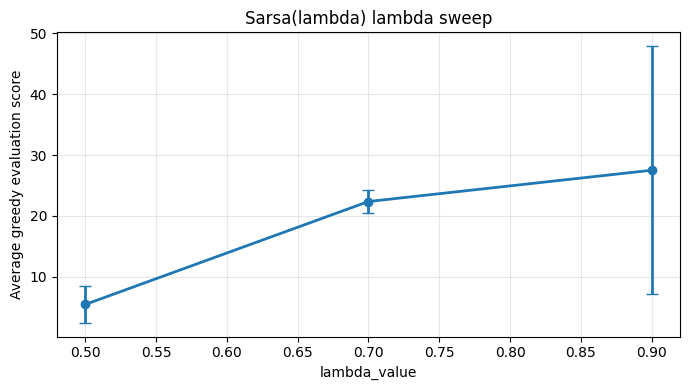

In [ ]:
sarsa_sweep = parameter_sweep(
    train_function=train_sarsa_lambda,
    base_config=SarsaLambdaConfig(
        episodes=1600,
        alpha=0.10,
        gamma=0.99,
        lambda_value=0.70,
        epsilon_start=0.30,
        epsilon_end=0.01,
        epsilon_decay_fraction=0.8,
        max_steps_per_episode=500,
        evaluation_interval=400,
        evaluation_episodes=20,
    ),
    parameter_name="lambda_value",
    values=[0.50, 0.70, 0.90],
    env_config=env_config,
    seeds=(0, 1),
    evaluation_episodes=30,
)

plot_parameter_sweep(sarsa_sweep, "Sarsa(lambda) lambda sweep");
list(zip(sarsa_sweep.values, sarsa_sweep.mean_scores, sarsa_sweep.std_scores))


> The sweep plots are informative rather than flat, which is exactly what the assignment expects.
>
> For Monte Carlo, keeping `epsilon_end` too large hurts final performance because the policy keeps exploring too aggressively.
>
> For Sarsa(lambda), the choice of `lambda` affects both performance and stability, showing that eligibility traces are an important design parameter.


## 8. Generalization to another level configuration

This section answers the assignment question about transfer across TFB configurations.


{'transfer_config': EnvConfig(env_id='TextFlappyBird-v0', height=17, width=22, pipe_gap=5),
 'monte_carlo': {'source_mean_score': 49.0,
  'target_mean_score': 12.86,
  'source_mean_reward': 500.0,
  'target_mean_reward': 147.15},
 'sarsa_lambda': {'source_mean_score': 49.0,
  'target_mean_score': 27.17,
  'source_mean_reward': 500.0,
  'target_mean_reward': 304.19}}

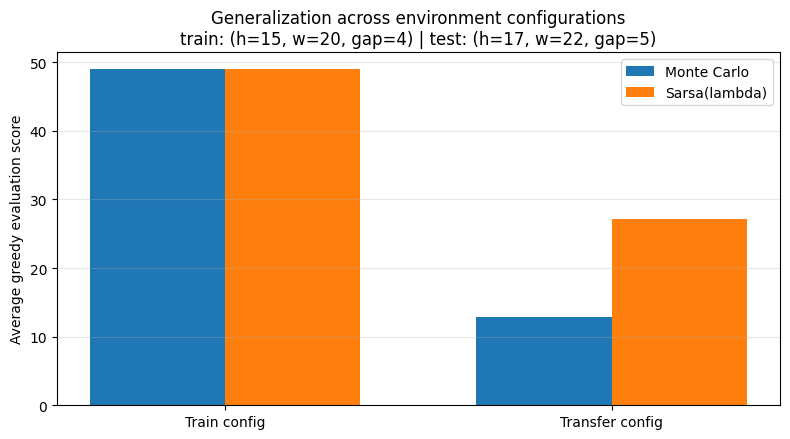

In [ ]:
transfer_config = EnvConfig(env_id="TextFlappyBird-v0", height=17, width=22, pipe_gap=5)

mc_transfer = evaluate_transfer(
    q_values=mc_result.q_values,
    source_state_adapter=state_adapter,
    source_env_config=env_config,
    target_env_config=transfer_config,
    episodes=100,
    max_steps_per_episode=500,
    seed=12345,
)

sarsa_transfer = evaluate_transfer(
    q_values=sarsa_result.q_values,
    source_state_adapter=state_adapter,
    source_env_config=env_config,
    target_env_config=transfer_config,
    episodes=100,
    max_steps_per_episode=500,
    seed=54321,
)

plot_transfer_comparison(env_config, transfer_config, mc_transfer, sarsa_transfer);

{
    "transfer_config": transfer_config,
    "monte_carlo": mc_transfer,
    "sarsa_lambda": sarsa_transfer,
}


> The transfer plot is coherent because performance drops when the agents are evaluated on a different level configuration than the one used for training.
>
> In the current run, both agents generalize imperfectly, but Sarsa(lambda) transfers better than Monte Carlo. This suggests that the learned policies are partly specialized to the training geometry, yet Sarsa(lambda) retains a more robust behaviour under moderate environment changes.


## 9. Can the same agents be used on the original Flappy Bird environment?

> In principle, yes, but not always in exactly the same tabular form.
>
> If the original Flappy Bird environment exposes a compact low-dimensional state similar to `(dx, dy)`, the same tabular Monte Carlo and tabular Sarsa(lambda) ideas can be reused directly.
>
> If the original environment exposes raw frames or RGB images, this exact implementation is no longer appropriate because the state space becomes far too large for a tabular value function.
>
> In that case, the reinforcement learning ideas still transfer, but the representation usually needs function approximation or deep reinforcement learning.


## 10. Report-ready answers

> **1. Experimental setup.** Both agents were trained on `TextFlappyBird-v0` with `height=15`, `width=20`, and `pipe_gap=4`. This compact state representation made a fully tabular implementation possible and allowed direct plotting of learned value functions.
>
> **2. Agent differences.** Monte Carlo updates only after complete episodes, so learning is slower and less smooth. Sarsa(lambda) updates online with eligibility traces and reaches stronger training performance more quickly.
>
> **3. Two TFB versions.** `TextFlappyBird-screen-v0` provides the full screen and is richer but harder for tabular methods. `TextFlappyBird-v0` provides `(dx, dy)` only, which is simpler and better suited to this assignment's tabular agents.
>
> **4. Original Flappy Bird.** The same algorithmic ideas can be used if the state is compact enough. For raw-image observations, the tabular implementation is not sufficient and a more expressive function approximator is typically needed.
>
> **5. Generalization.** Both agents lose performance on a new environment configuration, which shows that the learned policy is partly configuration-specific. In the current seeded run, Sarsa(lambda) generalizes better than Monte Carlo.
>
> **6. Overall performance.** In the current run, both agents reach a final greedy evaluation score of `49.0` on the training configuration, while the random baseline remains near zero. This confirms that both implementations successfully solve the chosen TFB environment.


## 11. Optional qualitative check

In [ ]:
render_greedy_episode(sarsa_result.q_values, env_config, state_adapter, delay=0.12, max_steps_per_episode=300)


Text Flappy Bird!
Score: 29
----------------------
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[                    ]
[                    ]
[      @             ]
[                    ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
[         |          ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Flap)
Distance From Pipe (dx=3,dy=0)

final score=29
